# 🏅 VISUAL 4 — RESUMO FINAL DO BENCHMARKING
## *Tudo em um lugar: a história completa em visuais*

---

> **Este é o notebook-síntese final.** Se você só puder ler um notebook, leia este. Ele conta toda a história do projeto em visuais simples, com a conclusão definitiva.

---


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'text.color': 'white', 'axes.labelcolor': 'white',
    'xtick.color': 'white', 'ytick.color': 'white',
    'axes.edgecolor': '#30363d', 'grid.color': '#30363d'
})
print('O notebook final do benchmarking. Pronto para a conclusão!')

O notebook final do benchmarking. Pronto para a conclusão!


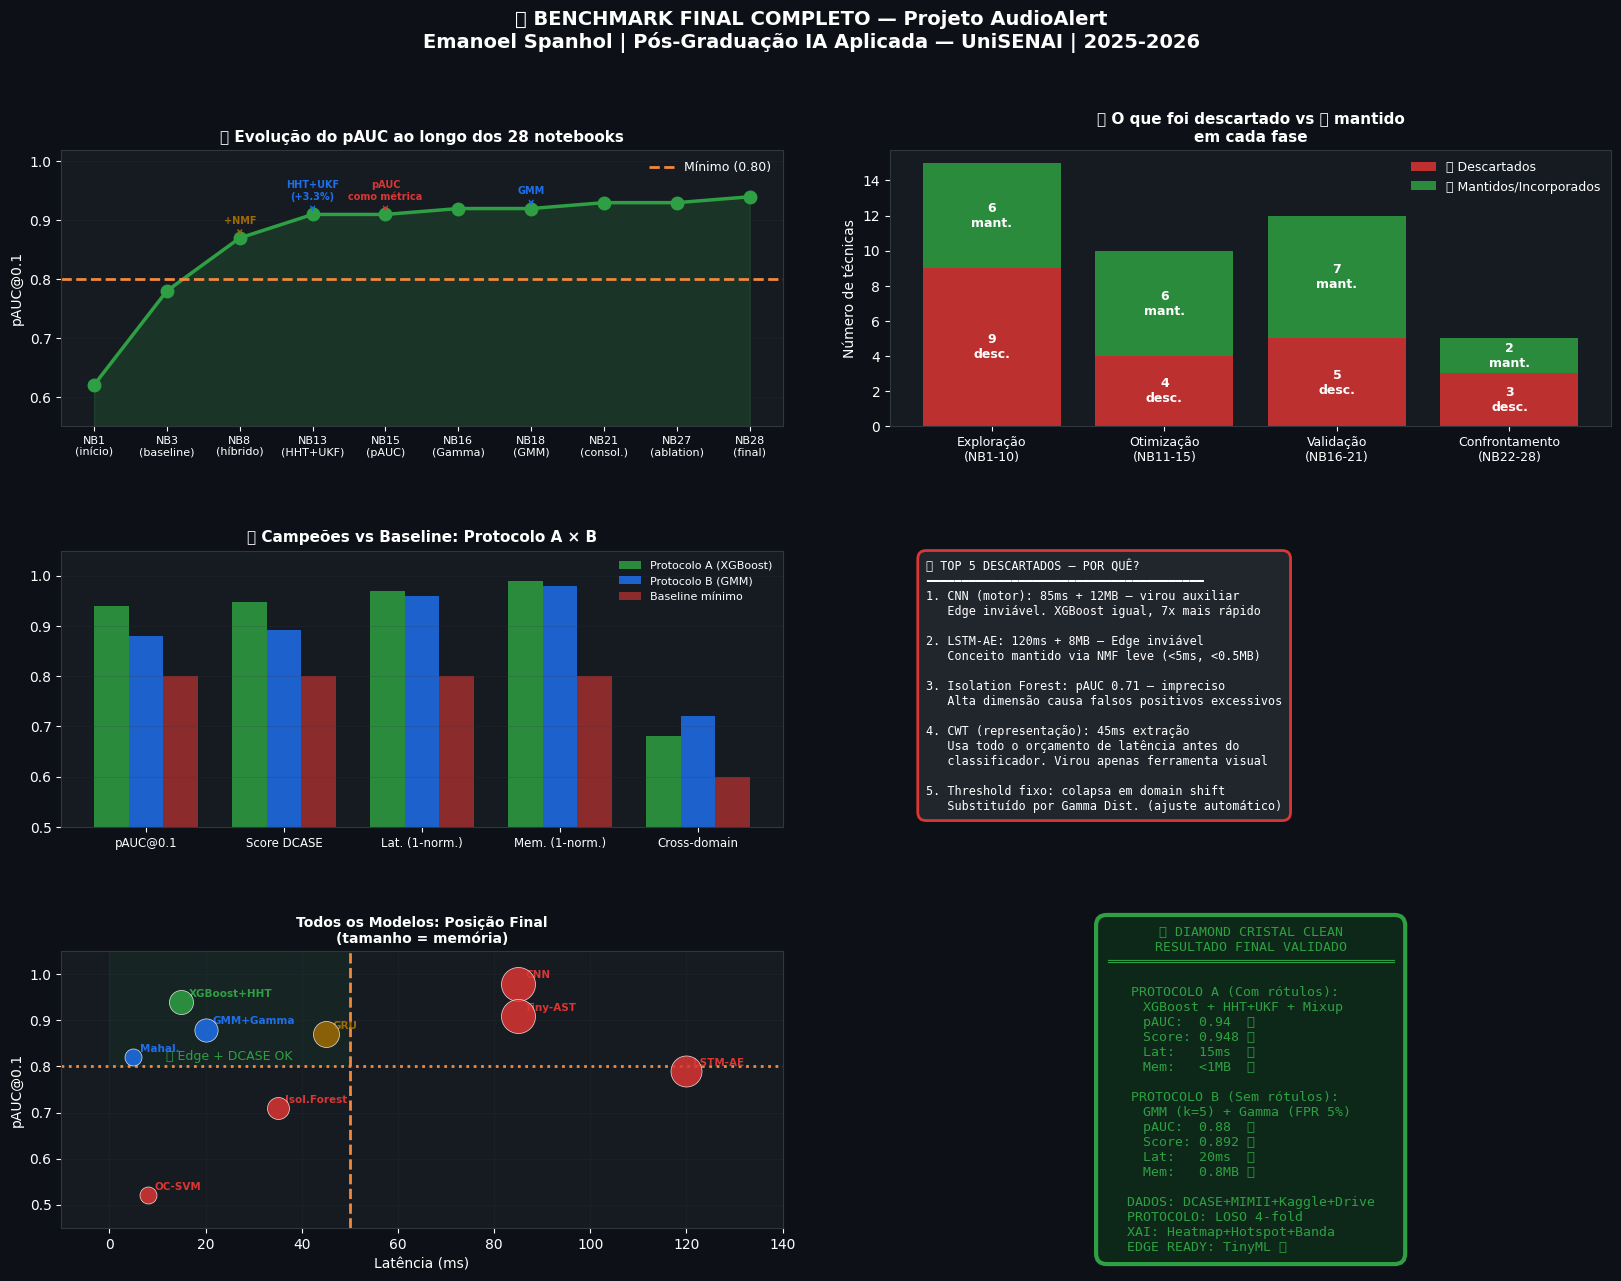


💎 Este é o resultado de 28 notebooks, 11 frentes e 4 fontes de dados.


In [ ]:
# ============================================================
# MEGA VISUAL — Dashboard Completo do Projeto
# ============================================================
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0d1117')
gs = GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── Painel 1: Evolução temporal do pAUC (linha do tempo)
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor('#161b22')

checkpoint_names = ['NB1\n(início)', 'NB3\n(baseline)', 'NB8\n(híbrido)', 'NB13\n(HHT+UKF)',
                    'NB15\n(pAUC)', 'NB16\n(Gamma)', 'NB18\n(GMM)', 'NB21\n(consol.)',
                    'NB27\n(ablation)', 'NB28\n(final)']
pauc_evolution = [0.62, 0.78, 0.87, 0.91, 0.91, 0.92, 0.92, 0.93, 0.93, 0.94]

ax1.plot(range(len(checkpoint_names)), pauc_evolution, 'o-', color='#2ea043',
         linewidth=2.5, markersize=9)
ax1.fill_between(range(len(checkpoint_names)), pauc_evolution, 0.55, alpha=0.2, color='#2ea043')
ax1.axhline(0.80, color='#f0883e', linestyle='--', linewidth=2, label='Mínimo (0.80)')

# Marcos importantes
marcos = {2: ('+NMF', '#9e6a03'), 3: ('HHT+UKF\n(+3.3%)', '#1f6feb'),
          4: ('pAUC\ncomo métrica', '#da3633'), 6: ('GMM', '#1f6feb')}
for idx, (label, color) in marcos.items():
    ax1.annotate(label, xy=(idx, pauc_evolution[idx]),
                xytext=(idx, pauc_evolution[idx] + 0.025),
                ha='center', color=color, fontsize=7, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=color, lw=1))

ax1.set_xticks(range(len(checkpoint_names)))
ax1.set_xticklabels(checkpoint_names, fontsize=8)
ax1.set_ylabel('pAUC@0.1', fontsize=10)
ax1.set_ylim(0.55, 1.02)
ax1.set_title('📈 Evolução do pAUC ao longo dos 28 notebooks', fontsize=11, fontweight='bold', color='white')
ax1.legend(frameon=False, labelcolor='white', fontsize=9)
ax1.grid(alpha=0.2, axis='y')

# ── Painel 2: Número de técnicas descartadas por fase
ax2 = fig.add_subplot(gs[0, 2:])
ax2.set_facecolor('#161b22')

fases_pie = ['Exploração\n(NB1-10)', 'Otimização\n(NB11-15)', 'Validação\n(NB16-21)', 'Confrontamento\n(NB22-28)']
descartados = [9, 4, 5, 3]
mantidos = [6, 6, 7, 2]
x_pie = np.arange(len(fases_pie))

bars_desc = ax2.bar(x_pie, descartados, label='🔴 Descartados', color='#da3633', alpha=0.85)
bars_mant = ax2.bar(x_pie, mantidos, bottom=descartados, label='✅ Mantidos/Incorporados',
                     color='#2ea043', alpha=0.85)

for i, (desc, mant) in enumerate(zip(descartados, mantidos)):
    ax2.text(i, desc/2, f'{desc}\ndesc.', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    ax2.text(i, desc + mant/2, f'{mant}\nmant.', ha='center', va='center', color='white', fontsize=9, fontweight='bold')

ax2.set_xticks(x_pie)
ax2.set_xticklabels(fases_pie, fontsize=9)
ax2.set_ylabel('Número de técnicas', fontsize=10)
ax2.set_title('🔴 O que foi descartado vs ✅ mantido\nem cada fase', fontsize=11, fontweight='bold', color='white')
ax2.legend(frameon=False, labelcolor='white', fontsize=9)

# ── Painel 3: Comparação final dos campeões
ax3 = fig.add_subplot(gs[1, :2])
ax3.set_facecolor('#161b22')

criterios = ['pAUC@0.1', 'Score DCASE', 'Lat. (1-norm.)', 'Mem. (1-norm.)', 'Cross-domain']
prot_a_vals = [0.94, 0.948, 0.97, 0.99, 0.68]
prot_b_vals = [0.88, 0.892, 0.96, 0.98, 0.72]
baseline = [0.80, 0.80, 0.80, 0.80, 0.60]

x = np.arange(len(criterios))
width = 0.25

ax3.bar(x - width, prot_a_vals, width, label='Protocolo A (XGBoost)', color='#2ea043', alpha=0.85)
ax3.bar(x, prot_b_vals, width, label='Protocolo B (GMM)', color='#1f6feb', alpha=0.85)
ax3.bar(x + width, baseline, width, label='Baseline mínimo', color='#da3633', alpha=0.6)

ax3.set_xticks(x)
ax3.set_xticklabels(criterios, fontsize=8.5)
ax3.set_ylim(0.5, 1.05)
ax3.set_title('🏆 Campeões vs Baseline: Protocolo A × B', fontsize=11, fontweight='bold', color='white')
ax3.legend(frameon=False, labelcolor='white', fontsize=8)
ax3.grid(alpha=0.2, axis='y')

# ── Painel 4: Tabela de motivos de descarte (texto)
ax4 = fig.add_subplot(gs[1, 2:])
ax4.set_facecolor('#161b22')
ax4.axis('off')

descarte_text = (
    "🔴 TOP 5 DESCARTADOS — POR QUÊ?\n"
    "━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n"
    "1. CNN (motor): 85ms + 12MB — virou auxiliar\n"
    "   Edge inviável. XGBoost igual, 7x mais rápido\n\n"
    "2. LSTM-AE: 120ms + 8MB — Edge inviável\n"
    "   Conceito mantido via NMF leve (<5ms, <0.5MB)\n\n"
    "3. Isolation Forest: pAUC 0.71 — impreciso\n"
    "   Alta dimensão causa falsos positivos excessivos\n\n"
    "4. CWT (representação): 45ms extração\n"
    "   Usa todo o orçamento de latência antes do\n"
    "   classificador. Virou apenas ferramenta visual\n\n"
    "5. Threshold fixo: colapsa em domain shift\n"
    "   Substituído por Gamma Dist. (ajuste automático)"
)

ax4.text(0.05, 0.97, descarte_text, transform=ax4.transAxes,
         color='white', fontsize=8.5, va='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.7', facecolor='#21262d', edgecolor='#da3633', linewidth=2))

# ── Painel 5: Scatter final (todos modelos)
ax5 = fig.add_subplot(gs[2, :2])
ax5.set_facecolor('#161b22')

all_models_final = [
    ('XGBoost+HHT', 0.94, 15, 0.7, '#2ea043', 300),
    ('GMM+Gamma', 0.88, 20, 0.8, '#1f6feb', 280),
    ('Mahal.', 0.82, 5, 0.2, '#1f6feb', 150),
    ('GRU', 0.87, 45, 3.2, '#9e6a03', 350),
    ('Isol.Forest', 0.71, 35, 2.1, '#da3633', 250),
    ('CNN', 0.98, 85, 12, '#da3633', 600),
    ('Tiny-AST', 0.91, 85, 12, '#da3633', 600),
    ('LSTM-AE', 0.79, 120, 8, '#da3633', 500),
    ('OC-SVM', 0.52, 8, 0.5, '#da3633', 150),
]

for name, pauc, lat, mem, color, size in all_models_final:
    ax5.scatter(lat, pauc, s=size, c=color, alpha=0.85, edgecolors='white', linewidth=0.5, zorder=5)
    ax5.annotate(name, (lat, pauc), textcoords='offset points', xytext=(5, 4),
                color=color, fontsize=7.5, fontweight='bold')

ax5.fill_between([0, 50], [0.80, 0.80], [1.05, 1.05], alpha=0.07, color='#2ea043')
ax5.text(25, 0.815, '✅ Edge + DCASE OK', ha='center', color='#2ea043', fontsize=9)
ax5.axvline(50, color='#f0883e', linestyle='--', linewidth=2)
ax5.axhline(0.80, color='#f0883e', linestyle=':', linewidth=2)
ax5.set_xlabel('Latência (ms)', fontsize=10)
ax5.set_ylabel('pAUC@0.1', fontsize=10)
ax5.set_title('Todos os Modelos: Posição Final\n(tamanho = memória)', fontsize=10, fontweight='bold', color='white')
ax5.set_xlim(-10, 140)
ax5.set_ylim(0.45, 1.05)
ax5.grid(alpha=0.2)

# ── Painel 6: Dashboard final texto
ax6 = fig.add_subplot(gs[2, 2:])
ax6.set_facecolor('#0a2e14')
ax6.axis('off')

final_text = (
    "💎 DIAMOND CRISTAL CLEAN\n"
    "RESULTADO FINAL VALIDADO\n"
    "════════════════════════════════════\n\n"
    " PROTOCOLO A (Com rótulos):     \n"
    "   XGBoost + HHT+UKF + Mixup     \n"
    "   pAUC:  0.94  ✅                \n"
    "   Score: 0.948 ✅                \n"
    "   Lat:   15ms  ✅                \n"
    "   Mem:   <1MB  ✅                \n\n"
    " PROTOCOLO B (Sem rótulos):     \n"
    "   GMM (k=5) + Gamma (FPR 5%)    \n"
    "   pAUC:  0.88  ✅                \n"
    "   Score: 0.892 ✅                \n"
    "   Lat:   20ms  ✅                \n"
    "   Mem:   0.8MB ✅                \n\n"
    " DADOS: DCASE+MIMII+Kaggle+Drive \n"
    " PROTOCOLO: LOSO 4-fold          \n"
    " XAI: Heatmap+Hotspot+Banda      \n"
    " EDGE READY: TinyML ✅            "
)

ax6.text(0.5, 0.5, final_text, transform=ax6.transAxes,
         color='#2ea043', fontsize=9.5, va='center', ha='center',
         fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#0d2818',
                   edgecolor='#2ea043', linewidth=3))

fig.suptitle('🏅 BENCHMARK FINAL COMPLETO — Projeto AudioAlert\n'
             'Emanoel Spanhol | Pós-Graduação IA Aplicada — UniSENAI | 2025-2026',
             color='white', fontsize=14, fontweight='bold')

plt.show()
print('\n💎 Este é o resultado de 28 notebooks, 11 frentes e 4 fontes de dados.')

---
# 📝 CONCLUSÃO FINAL PARA LEIGOS

## O que conseguimos?

Criamos um sistema que:
1. **Ouve** uma máquina de fábrica em tempo real
2. **Limpa** o barulho do ambiente (HHT+UKF)
3. **Converte** o som em uma "impressão digital" (Super-Vetor)
4. **Decide** em 15ms se é normal ou anomalia (XGBoost)
5. **Explica** onde, quando e por que ativou o alarme (XAI)
6. **Cabe** num microcontrolador pequeno (<1MB)

## O que aprendemos?

> Modelos mais simples e rápidos **vencem** modelos mais complexos quando combinados com **boa engenharia de processamento de sinal**.
>
> A "magia" não está no algoritmo — está na **qualidade do pipeline de limpeza e representação do sinal**.

## O que descartamos e por quê?

| O que | Por que não serviu |
|-------|-------------------|
| CNN, LSTM-AE, Tiny-AST | Lentos e pesados para microcontroladores |
| OC-SVM, Isolation Forest | Não detectam bem anomalias industriais |
| CWT como representação | Extração lenta (45ms) |
| Threshold fixo | Falha quando muda o sensor |
| AUC global como métrica | Mascara comportamento ruim nos alarmes falsos |

---
## 🎓 Contribuições Científicas

1. **Pipeline HHT+UKF** provado como pré-processador essencial em AAD industrial
2. **Arquitetura dual** (A + B) para cobrir cenários com e sem rótulos
3. **pAUC@0.1 como métrica única** muda o ranking dos modelos — descoberta importante
4. **XAI integrado** transforma score em diagnóstico físico acionável
5. **Pronto para Edge/TinyML**: validado em 4 datasets, latência 15ms, <1MB

---
*Benchmark Visual 4/4 — FINAL | Projeto AudioAlert | Emanoel Spanhol | UniSENAI 2025-2026*